# Chapter 10: Gluing

**Source orientation:** McDuff-Salamon, *J-holomorphic Curves and Symplectic Topology*, Chapter 10, printed pp. 369-416; PDF pp. 384-431. Sections 10.1-10.9.

## Chapter Goal

Gluing is the local inverse of bubbling. Starting from two regular curves that meet at a node, the chapter builds a long-neck approximate curve, measures its Cauchy-Riemann defect in weighted norms, corrects it by a Newton/implicit-function argument, and then uses the resulting local model to prove the splitting axiom for Gromov-Witten invariants.

This notebook turns that analytic proof into inspectable finite models. The models do not prove the theorem by themselves; they expose the scale choices, cutoff estimates, right-inverse logic, and counting consequences that the theorem needs.


## Computational Translation Guide

| Chapter object | Computational representation | What to inspect |
| --- | --- | --- |
| Connected pair `(u0, uinf)` with `u0(0)=uinf(inf)` | Two domains joined across an annular neck | Which radii belong to the `u0`, constant, transition, and rescaled `uinf` regions |
| Preglued map `u^R` | Piecewise annular construction with a transition cutoff | The defect lives only where the cutoff changes |
| Weighted norms | Rescaled metric density `theta_R^{-2}` | The tiny inner disk receives the same weight as the outer sphere after rescaling |
| Logarithmic cutoff | Radial cutoff with derivative energy `2*pi/log(eps/delta)` | The operator norm shrinks as the annulus becomes long |
| Approximate and exact right inverses | Finite dependency diagram and contraction ledger | `T` is almost inverse; `Q = T(DT)^{-1}` is the exact inverse used by Newton |
| Derivative of the gluing map | Tangent projection diagram | Pregluing controls the tangent kernel, and the Newton correction has small derivative |
| Surjectivity | Successive approximation ladder | Weak `C0` closeness is upgraded to the normal form required for uniqueness |
| Splitting axiom | Evaluation/intersection graph | The diagonal class turns a single count into paired counts joined at the node |
| Revisited theorem | Cross-ratio/gluing-parameter picture | `lambda = exp(i theta)/R^2` moves a smooth four-marked curve toward the nodal boundary |


In [1]:
from pathlib import Path
import io
import json
import math

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch, Rectangle
import networkx as nx
import numpy as np
import pandas as pd
import sympy as sp
from IPython.display import HTML, Image, display

trapz = getattr(np, "trapezoid", np.trapz)


def find_book_root():
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents]
    for base in candidates:
        direct = base / "J-Holomorphic-Curves-and-Symplectic-Topology"
        if direct.exists() and (direct / "SOURCE_MAP.md").exists():
            return direct
        if base.name == "J-Holomorphic-Curves-and-Symplectic-Topology" and (base / "SOURCE_MAP.md").exists():
            return base
    raise FileNotFoundError("Could not locate J-Holomorphic-Curves-and-Symplectic-Topology")


BOOK_ROOT = find_book_root()
CHAPTER = BOOK_ROOT / "chapter-10-gluing"
ART_ROOT = BOOK_ROOT / "artifacts" / "chapter-10"
FIG_DIR = ART_ROOT / "figures"
HTML_DIR = ART_ROOT / "html"
CHECK_DIR = ART_ROOT / "checks"
TABLE_DIR = ART_ROOT / "tables"
for folder in [FIG_DIR, HTML_DIR, CHECK_DIR, TABLE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

ARTIFACTS = []


def record(path):
    path = Path(path)
    if path not in ARTIFACTS:
        ARTIFACTS.append(path)
    return path


def rel(path):
    return Path(path).resolve().relative_to(BOOK_ROOT.resolve()).as_posix()


def write_json(path, payload):
    path = record(path)
    path.write_text(json.dumps(payload, indent=2, sort_keys=True), encoding="utf-8")
    return path


def save_figure(fig, path, **kwargs):
    path = record(path)
    save_kwargs = {"dpi": 170, **kwargs}
    save_kwargs.setdefault("format", path.suffix.lower().lstrip(".") or "png")
    buffer = io.BytesIO()
    try:
        fig.savefig(buffer, **save_kwargs)
    except OSError:
        if save_kwargs.get("bbox_inches") != "tight":
            raise
        fallback_kwargs = dict(save_kwargs)
        fallback_kwargs["bbox_inches"] = None
        buffer = io.BytesIO()
        fig.savefig(buffer, **fallback_kwargs)
    path.write_bytes(buffer.getvalue())
    return path


def display_artifact(path, width=760):
    path = Path(path)
    display(HTML(f"<div><code>{rel(path)}</code></div>"))
    if path.suffix.lower() in {".png", ".jpg", ".jpeg"}:
        display(Image(filename=str(path), width=width))
    elif path.suffix.lower() == ".html":
        display(HTML(f'<a href="{rel(path)}" target="_blank">open interactive artifact</a>'))
    elif path.suffix.lower() in {".json", ".csv"}:
        text = path.read_text(encoding="utf-8")
        display(HTML(f"<pre>{text[:4000]}</pre>"))
    else:
        display(HTML(f"<a href='{rel(path)}'>{path.name}</a>"))


def assert_artifact(path, min_bytes=1):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    size = path.stat().st_size
    if size < min_bytes:
        raise AssertionError(f"artifact too small: {path} has {size} bytes, expected at least {min_bytes}")
    return path


plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 170,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
})

print(f"Book root: {BOOK_ROOT}")
print(f"Artifact root: {ART_ROOT}")


Book root: D:\Geometry\J-Holomorphic-Curves-and-Symplectic-Topology
Artifact root: D:\Geometry\J-Holomorphic-Curves-and-Symplectic-Topology\artifacts\chapter-10


## Source Coverage, Routing, And Storyboard

The notebook covers the full Chapter 10 source span. The table below records how each section is represented computationally. The routing table follows the repo library catalog: Matplotlib is used for durable annular and estimate diagrams, NetworkX for proof/counterflow structure, SymPy for exact identities, Plotly for a small interactive error explorer, and pandas/JSON for ledgers and sanity checks.


In [2]:
coverage_rows = [
    {"section": "10.1", "source_topic": "gluing theorem", "notebook_section": "proof pipeline and theorem revisit", "artifact": "proof-dependency-map.png"},
    {"section": "10.2", "source_topic": "connected sums of curves", "notebook_section": "connected-sum annuli", "artifact": "connected-sum-domain-annuli.png"},
    {"section": "10.3", "source_topic": "weighted norms", "notebook_section": "metric balance and volume checks", "artifact": "weighted-norm-balance.png"},
    {"section": "10.4", "source_topic": "cutoff functions", "notebook_section": "log cutoff profile", "artifact": "cutoff-log-profile.png"},
    {"section": "10.5", "source_topic": "construction of the gluing map", "notebook_section": "neck error and Newton correction", "artifact": "neck-error-newton-correction.png"},
    {"section": "10.6", "source_topic": "derivative of the gluing map", "notebook_section": "linearization diagram", "artifact": "derivative-gluing-map.png"},
    {"section": "10.7", "source_topic": "surjectivity", "notebook_section": "successive approximation ladder", "artifact": "surjectivity-newton-steps.png"},
    {"section": "10.8", "source_topic": "splitting axiom", "notebook_section": "evaluation and diagonal split", "artifact": "splitting-axiom-flow.png"},
    {"section": "10.9", "source_topic": "gluing theorem revisited", "notebook_section": "cross-ratio neighborhood", "artifact": "gluing-theorem-revisited-cross-ratio.png"},
]
coverage_df = pd.DataFrame(coverage_rows)
coverage_path = record(TABLE_DIR / "source-coverage.csv")
coverage_df.to_csv(coverage_path, index=False)
source_coverage_payload = {
    "source": "McDuff-Salamon, J-holomorphic Curves and Symplectic Topology, Chapter 10",
    "source_span_used": "printed pp. 369-416; PDF pp. 384-431",
    "read_method": "assigned source span read with pdftotext; no textbook prose or figures copied",
    "sections": coverage_rows,
    "passed": len(coverage_rows) == 9,
}
source_coverage_json = write_json(CHECK_DIR / "source-coverage.json", source_coverage_payload)

routing_rows = [
    {"concept": "proof dependency of gluing theorem", "representation": "directed acyclic graph", "library": "NetworkX + Matplotlib", "why": "the proof is a dependency pipeline, not a surface or mesh", "fallback": "pandas edge table"},
    {"concept": "connected-sum annuli", "representation": "scaled radial domain diagram", "library": "Matplotlib", "why": "radii and support regions are two-dimensional and static", "fallback": "SVG drawn by Matplotlib"},
    {"concept": "weighted norm balance", "representation": "density plot and exact volume ledger", "library": "Matplotlib + SymPy", "why": "the key invariant is an exact radial integral", "fallback": "numeric quadrature only"},
    {"concept": "log cutoff estimate", "representation": "profile plus derivative energy", "library": "Matplotlib + SymPy", "why": "the borderline estimate is an explicit radial identity", "fallback": "sampled numpy integral"},
    {"concept": "neck error and Newton contraction", "representation": "parameter family of error curves", "library": "Plotly + Matplotlib", "why": "varying delta and R clarifies the long-neck limit", "fallback": "static PNG"},
    {"concept": "derivative and surjectivity", "representation": "linear maps and approximation ladder", "library": "Matplotlib", "why": "the proof is finite-dimensional normal-form bookkeeping", "fallback": "markdown table"},
    {"concept": "splitting axiom", "representation": "evaluation graph and diagonal decomposition", "library": "NetworkX + SymPy", "why": "the count splits along a graph edge and a pairing identity", "fallback": "pandas ledger"},
    {"concept": "theorem 10.9 revisit", "representation": "cross-ratio/gluing parameter diagram", "library": "Matplotlib + numpy", "why": "the gluing parameter is a complex disk coordinate", "fallback": "static table of lambda values"},
]
routing_df = pd.DataFrame(routing_rows)
routing_path = record(TABLE_DIR / "library-routing.csv")
routing_df.to_csv(routing_path, index=False)
library_routing_json = write_json(CHECK_DIR / "library-routing.json", {"routes": routing_rows, "passed": len(routing_rows) >= 8})

storyboard = {
    "chapter_goal": "Explain gluing as the analytic inverse of bubbling and as the input to the splitting axiom.",
    "source_span_read": "Chapter 10, printed pp. 369-416; PDF pp. 384-431; sections 10.1-10.9.",
    "visual_sequence": [
        {"concept": row["source_topic"], "artifact": row["artifact"], "inspection_target": row["notebook_section"]}
        for row in coverage_rows
    ],
    "computational_checks": [
        "weighted inner and outer volumes agree exactly",
        "log cutoff derivative energy matches 2*pi/log(eps/delta)",
        "neck error and Newton correction decrease as the neck length grows",
        "proof graph is acyclic and covers all assigned concepts",
        "final artifact assertions verify existence and nonzero size",
    ],
    "library_routing": routing_rows,
}
storyboard_path = write_json(CHECK_DIR / "visual-storyboard.json", storyboard)

source_sections = set(coverage_df["section"])
display(coverage_df)
display(routing_df)
display_artifact(source_coverage_json, width=700)
display_artifact(storyboard_path, width=700)
display_artifact(library_routing_json, width=700)


,section,source_topic,notebook_section,artifact
0,10.1,gluing theorem,proof pipeline and theorem revisit,proof-dependency-map.png
1,10.2,connected sums of curves,connected-sum annuli,connected-sum-domain-annuli.png
2,10.3,weighted norms,metric balance and volume checks,weighted-norm-balance.png
3,10.4,cutoff functions,log cutoff profile,cutoff-log-profile.png
4,10.5,construction of the gluing map,neck error and Newton correction,neck-error-newton-correction.png
5,10.6,derivative of the gluing map,linearization diagram,derivative-gluing-map.png
6,10.7,surjectivity,successive approximation ladder,surjectivity-newton-steps.png
7,10.8,splitting axiom,evaluation and diagonal split,splitting-axiom-flow.png
8,10.9,gluing theorem revisited,cross-ratio neighborhood,gluing-theorem-revisited-cross-ratio.png


,concept,representation,library,why,fallback
0,proof dependency of gluing theorem,directed acyclic graph,NetworkX + Matplotlib,"the proof is a dependency pipeline, not a surf...",pandas edge table
1,connected-sum annuli,scaled radial domain diagram,Matplotlib,radii and support regions are two-dimensional ...,SVG drawn by Matplotlib
2,weighted norm balance,density plot and exact volume ledger,Matplotlib + SymPy,the key invariant is an exact radial integral,numeric quadrature only
3,log cutoff estimate,profile plus derivative energy,Matplotlib + SymPy,the borderline estimate is an explicit radial ...,sampled numpy integral
4,neck error and Newton contraction,parameter family of error curves,Plotly + Matplotlib,varying delta and R clarifies the long-neck limit,static PNG
5,derivative and surjectivity,linear maps and approximation ladder,Matplotlib,the proof is finite-dimensional normal-form bo...,markdown table
6,splitting axiom,evaluation graph and diagonal decomposition,NetworkX + SymPy,the count splits along a graph edge and a pair...,pandas ledger
7,theorem 10.9 revisit,cross-ratio/gluing parameter diagram,Matplotlib + numpy,the gluing parameter is a complex disk coordinate,static table of lambda values


## Proof Pipeline: What Must Be Controlled Before Gluing Exists

The theorem is easy to misread as a single implicit-function-theorem application. The proof has more structure. Pregluing provides a candidate curve, weighted norms make the two components comparable, cutoff estimates make the approximate inverse accurate, and only then can Newton correction produce an actual curve. Surjectivity is a separate converse-to-compactness argument, not a formal consequence of injectivity.


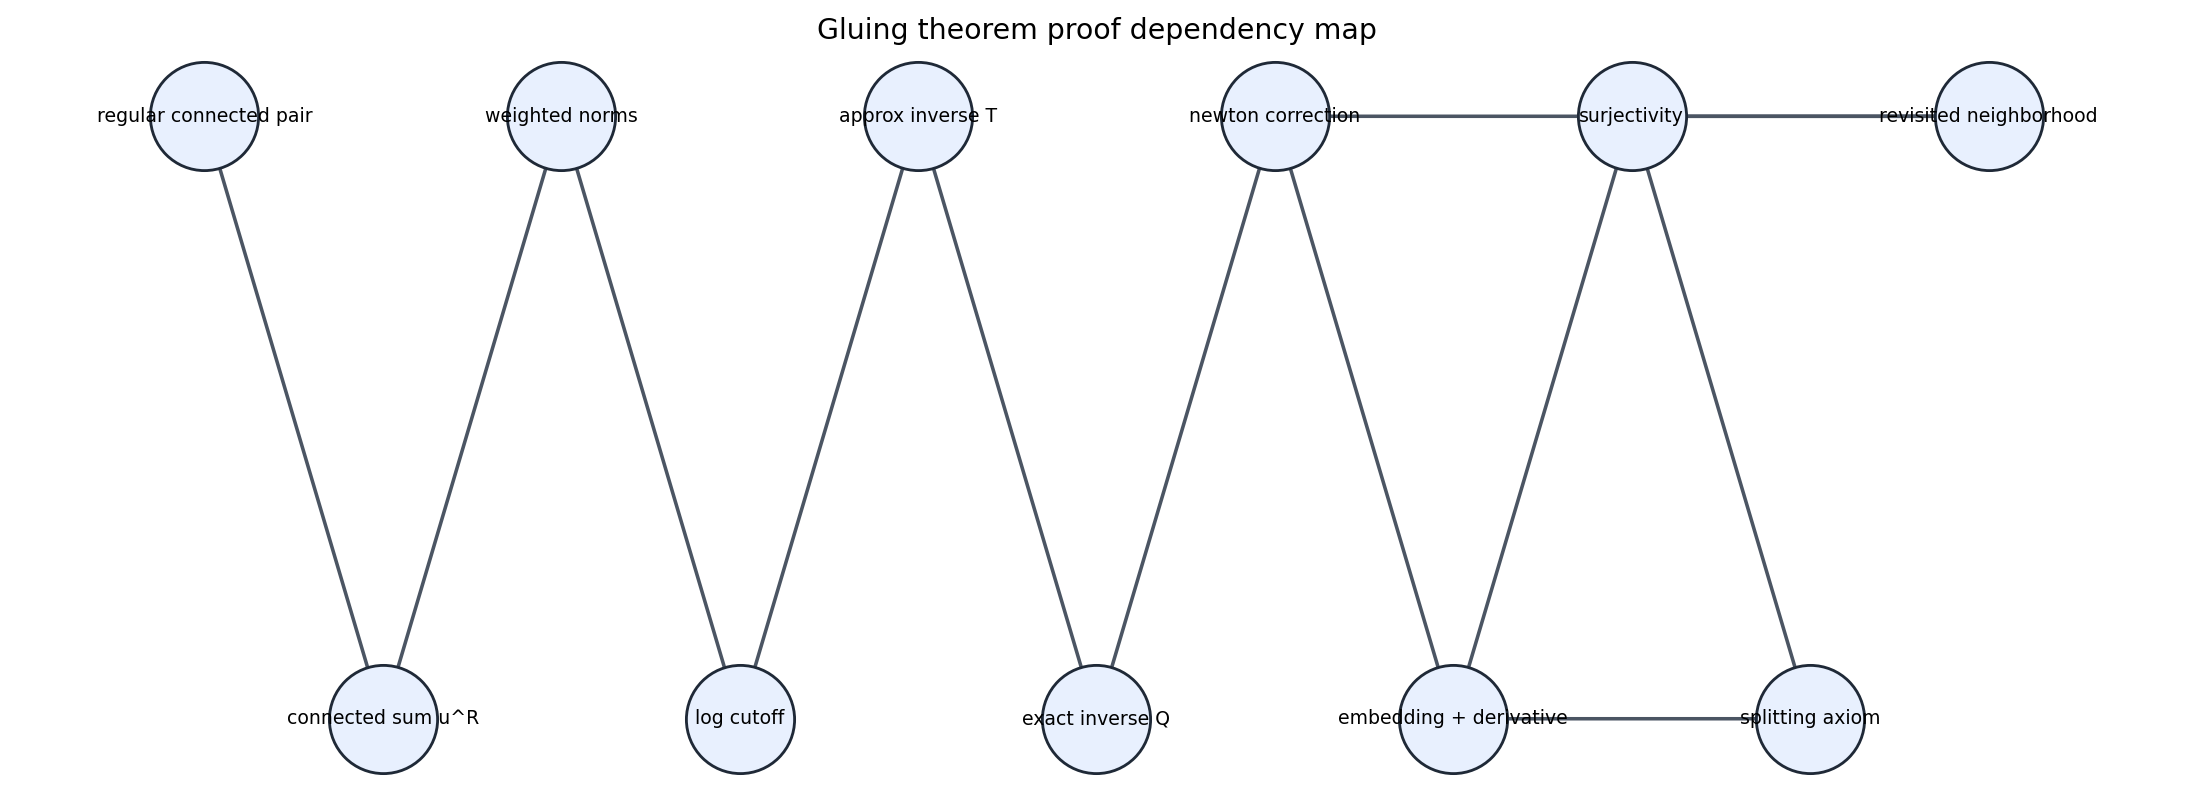

In [3]:
proof_nodes = [
    "regular connected pair",
    "connected sum u^R",
    "weighted norms",
    "log cutoff",
    "approx inverse T",
    "exact inverse Q",
    "newton correction",
    "embedding + derivative",
    "surjectivity",
    "splitting axiom",
    "revisited neighborhood",
]
proof_edges = [
    ("regular connected pair", "connected sum u^R"),
    ("connected sum u^R", "weighted norms"),
    ("weighted norms", "log cutoff"),
    ("log cutoff", "approx inverse T"),
    ("approx inverse T", "exact inverse Q"),
    ("exact inverse Q", "newton correction"),
    ("newton correction", "embedding + derivative"),
    ("embedding + derivative", "surjectivity"),
    ("embedding + derivative", "splitting axiom"),
    ("surjectivity", "splitting axiom"),
    ("surjectivity", "revisited neighborhood"),
    ("newton correction", "revisited neighborhood"),
]
G = nx.DiGraph()
G.add_nodes_from(proof_nodes)
G.add_edges_from(proof_edges)
levels = {node: idx for idx, node in enumerate(proof_nodes)}
pos = {node: (levels[node], -0.25 * (i % 2)) for i, node in enumerate(proof_nodes)}

fig, ax = plt.subplots(figsize=(13, 4.8))
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=14, width=1.5, edge_color="#4b5563")
nx.draw_networkx_nodes(G, pos, ax=ax, node_color="#e8f0fe", edgecolors="#1f2937", node_size=2100, linewidths=1.2)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8)
ax.set_title("Gluing theorem proof dependency map")
ax.axis("off")
fig.tight_layout()
proof_fig = record(FIG_DIR / "proof-dependency-map.png")
save_figure(fig, proof_fig, bbox_inches="tight")
plt.close(fig)

required_terms = {"connected sum", "weighted norms", "log cutoff", "newton correction", "surjectivity", "splitting axiom"}
covered_terms = " ".join(proof_nodes).lower()
proof_checks = {
    "source_span": "printed 369-416; PDF 384-431",
    "nodes": len(G.nodes),
    "edges": len(G.edges),
    "is_directed_acyclic_graph": nx.is_directed_acyclic_graph(G),
    "required_terms_present": {term: (term.lower() in covered_terms) for term in required_terms},
    "passed": bool(nx.is_directed_acyclic_graph(G) and all(term.lower() in covered_terms for term in required_terms)),
}
proof_json = write_json(CHECK_DIR / "proof-dependency-map.json", proof_checks)

display_artifact(proof_fig)
display_artifact(proof_json)


## Connected Sums Of Curves: The Preglued Domain

The preglued curve agrees with the outer curve away from the node, agrees with the rescaled inner curve near the node, and is flattened to the common intersection point across the central neck. The defect is not spread across the whole sphere; it is concentrated in the transition annuli where cutoffs are active.

In the model below, `R` controls the neck length and `delta` controls how much room the analysis reserves around the middle circle `|z|=1/R`.


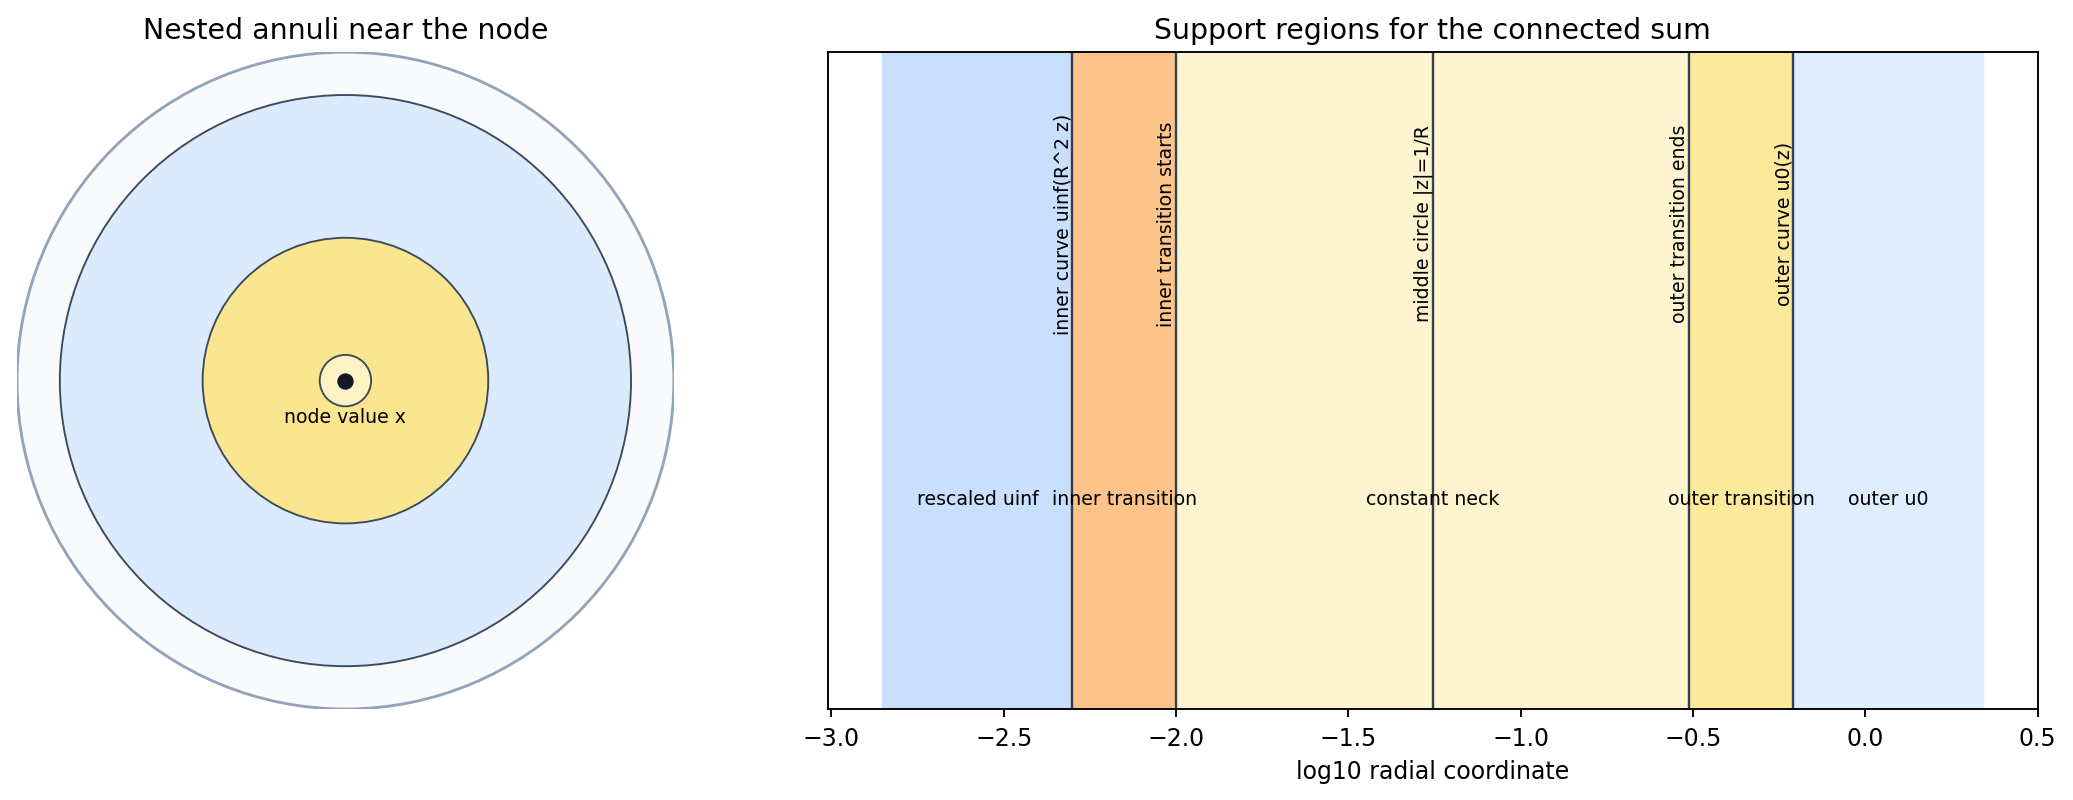

In [4]:
R_model = 18.0
delta_model = 0.18
radii = {
    "inner curve uinf(R^2 z)": delta_model / (2 * R_model),
    "inner transition starts": delta_model / R_model,
    "middle circle |z|=1/R": 1 / R_model,
    "outer transition ends": 1 / (delta_model * R_model),
    "outer curve u0(z)": 2 / (delta_model * R_model),
}
ordered = list(radii.values())
annulus_order_ok = all(a < b for a, b in zip(ordered, ordered[1:]))
neck_log_width = math.log((1 / (delta_model * R_model)) / (delta_model / R_model))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw={"width_ratios": [1, 1.35]})
ax = axes[0]
max_radius = radii["outer curve u0(z)"] * 1.15
ax.add_patch(Circle((0, 0), max_radius, facecolor="#f8fafc", edgecolor="#94a3b8", lw=1.2))
for radius, color in [
    (radii["outer curve u0(z)"], "#dbeafe"),
    (radii["outer transition ends"], "#fde68a"),
    (radii["middle circle |z|=1/R"], "#fef3c7"),
    (radii["inner transition starts"], "#fdba74"),
    (radii["inner curve uinf(R^2 z)"], "#bfdbfe"),
]:
    ax.add_patch(Circle((0, 0), radius, facecolor=color, edgecolor="#334155", lw=0.8, alpha=0.95))
ax.scatter([0], [0], s=35, color="#111827", zorder=5)
ax.text(0, -max_radius * 0.08, "node value x", ha="center", va="top", fontsize=8)
ax.set_aspect("equal")
ax.set_xlim(-max_radius, max_radius)
ax.set_ylim(-max_radius, max_radius)
ax.set_title("Nested annuli near the node")
ax.axis("off")

ax = axes[1]
log_r = np.log10(np.array(ordered))
labels = list(radii.keys())
for x, lab in zip(log_r, labels):
    ax.axvline(x, color="#334155", lw=1)
    ax.text(x, 0.74, lab, rotation=90, va="center", ha="right", fontsize=8)
regions = [
    (log_r[0] - 0.55, log_r[0], "rescaled uinf", "#bfdbfe"),
    (log_r[0], log_r[1], "inner transition", "#fdba74"),
    (log_r[1], log_r[3], "constant neck", "#fef3c7"),
    (log_r[3], log_r[4], "outer transition", "#fde68a"),
    (log_r[4], log_r[4] + 0.55, "outer u0", "#dbeafe"),
]
for x0, x1, lab, color in regions:
    ax.axvspan(x0, x1, color=color, alpha=0.85)
    ax.text((x0 + x1) / 2, 0.32, lab, ha="center", va="center", fontsize=8)
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_xlabel("log10 radial coordinate")
ax.set_title("Support regions for the connected sum")
fig.tight_layout()
conn_fig = record(FIG_DIR / "connected-sum-domain-annuli.png")
save_figure(fig, conn_fig, bbox_inches="tight")
plt.close(fig)

connected_sum_checks = {
    "R": R_model,
    "delta": delta_model,
    "radii": radii,
    "annulus_order_ok": annulus_order_ok,
    "neck_log_width": neck_log_width,
    "defect_regions": ["inner transition", "outer transition"],
    "passed": bool(annulus_order_ok and neck_log_width > 0),
}
conn_json = write_json(CHECK_DIR / "connected-sum-annuli-checks.json", connected_sum_checks)

display_artifact(conn_fig)
display_artifact(conn_json)


## Weighted Norms: Why The Tiny Disk Does Not Disappear

The inner component is rescaled into a disk of radius `1/R`. Ordinary area would make that disk look negligible. Chapter 10 instead uses the metric density determined by

`theta_R(z) = R^{-2} + R^2 |z|^2` for `|z| <= 1/R`, and `theta_R(z) = 1 + |z|^2` for `|z| >= 1/R`.

With this choice, the involution `z -> 1/(R^2 z)` exchanges the two sides of the neck, and the weighted area of the inner disk equals the weighted area of the outer region.


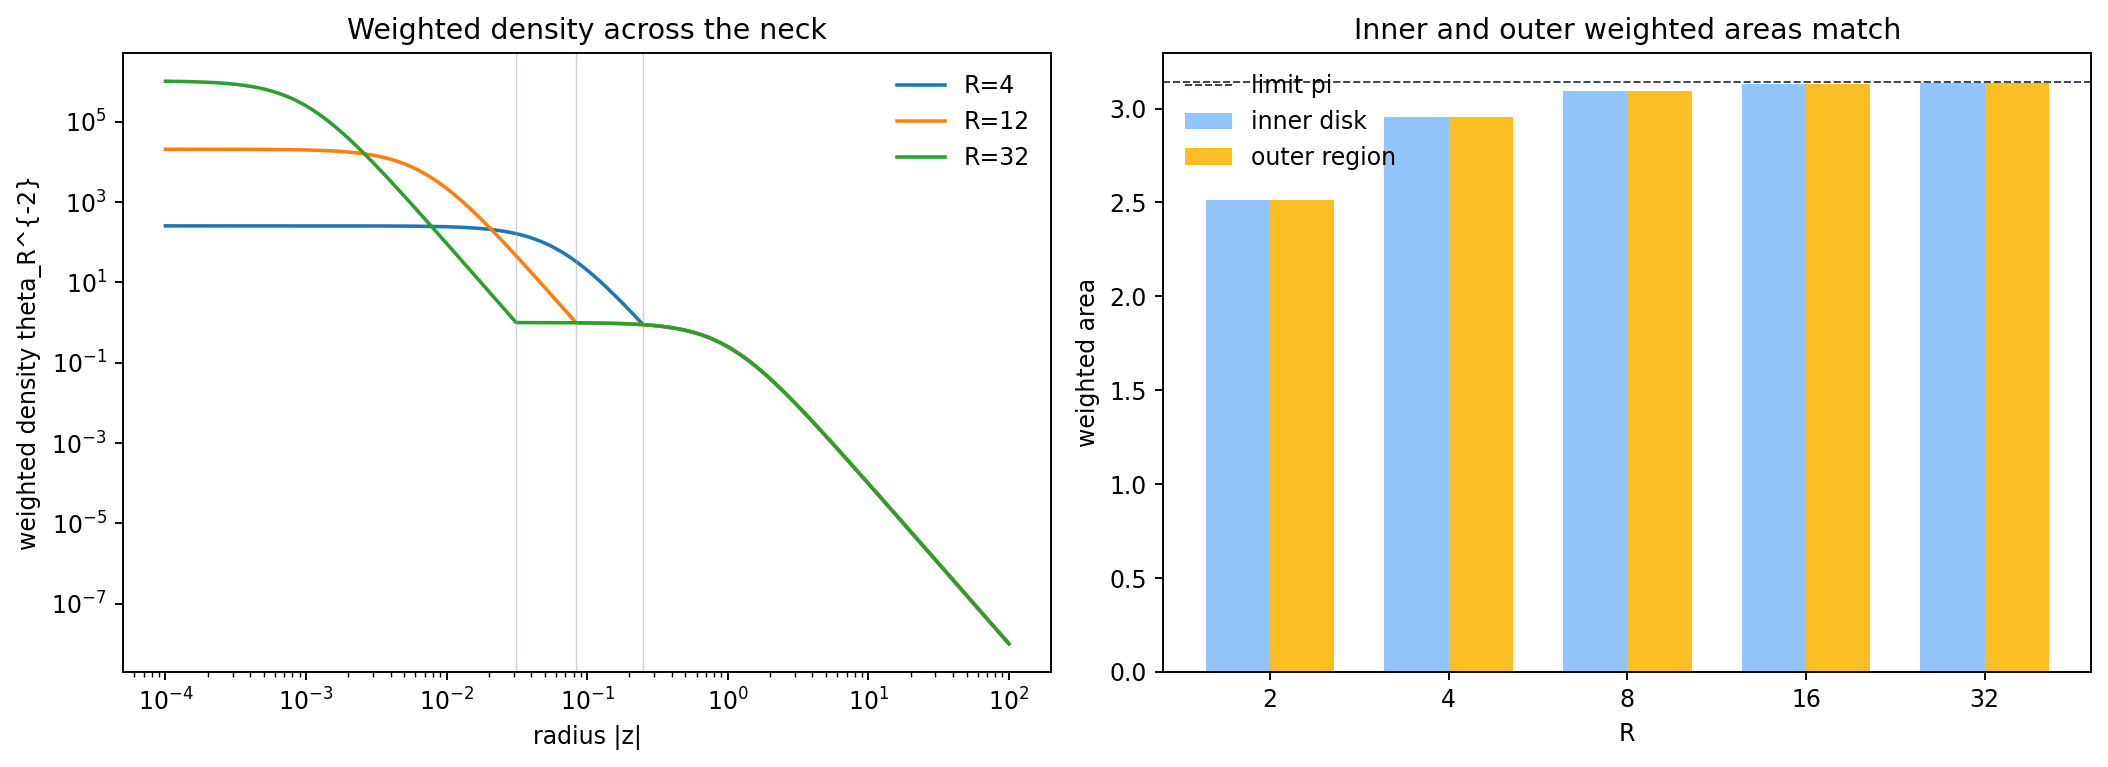

In [5]:
r, R = sp.symbols("r R", positive=True)
inner_integral = sp.integrate(2 * sp.pi * r / (R**-2 + R**2 * r**2)**2, (r, 0, 1/R))
outer_integral = sp.integrate(2 * sp.pi * r / (1 + r**2)**2, (r, 1/R, sp.oo))
inner_simplified = sp.simplify(inner_integral)
outer_simplified = sp.simplify(outer_integral)
volume_difference = sp.simplify(inner_simplified - outer_simplified)


def theta_R(radius, R_value):
    radius = np.asarray(radius)
    return np.where(radius <= 1 / R_value, R_value**-2 + R_value**2 * radius**2, 1 + radius**2)


R_values = np.array([2, 4, 8, 16, 32], dtype=float)
inner_values = np.array([float(inner_simplified.subs(R, val)) for val in R_values])
outer_values = np.array([float(outer_simplified.subs(R, val)) for val in R_values])
total_values = inner_values + outer_values

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
radius_grid = np.logspace(-4, 2, 800)
for R_value in [4, 12, 32]:
    density = theta_R(radius_grid, R_value) ** -2
    axes[0].loglog(radius_grid, density, label=f"R={R_value}")
    axes[0].axvline(1 / R_value, color="#94a3b8", lw=0.6, alpha=0.5)
axes[0].set_xlabel("radius |z|")
axes[0].set_ylabel("weighted density theta_R^{-2}")
axes[0].set_title("Weighted density across the neck")
axes[0].legend(frameon=False)

x = np.arange(len(R_values))
axes[1].bar(x - 0.18, inner_values, width=0.36, label="inner disk", color="#93c5fd")
axes[1].bar(x + 0.18, outer_values, width=0.36, label="outer region", color="#fbbf24")
axes[1].axhline(math.pi, color="#334155", lw=0.8, ls="--", label="limit pi")
axes[1].set_xticks(x)
axes[1].set_xticklabels([str(int(v)) for v in R_values])
axes[1].set_xlabel("R")
axes[1].set_ylabel("weighted area")
axes[1].set_title("Inner and outer weighted areas match")
axes[1].legend(frameon=False)
fig.tight_layout()
weighted_fig = record(FIG_DIR / "weighted-norm-balance.png")
save_figure(fig, weighted_fig, bbox_inches="tight")
plt.close(fig)

weighted_checks = {
    "inner_integral": str(inner_simplified),
    "outer_integral": str(outer_simplified),
    "symbolic_difference": str(volume_difference),
    "max_numeric_difference": float(np.max(np.abs(inner_values - outer_values))),
    "max_total_area": float(np.max(total_values)),
    "two_pi": float(2 * math.pi),
    "passed": bool(volume_difference == 0) and float(np.max(total_values)) <= 2 * math.pi + 1e-12,
}
weighted_json = write_json(CHECK_DIR / "weighted-norm-balance.json", weighted_checks)

display_artifact(weighted_fig)
display_artifact(weighted_json)


## Cutoff Functions: Small Derivative On A Long Annulus

The special cutoff is logarithmic on an annulus. Its derivative is not pointwise small, but its `L^2` energy is `2*pi/log(eps/delta)`. This is the borderline two-dimensional estimate that lets cutoff multiplication become small when the annulus is long.

The proof later combines this with the fact that relevant vector fields vanish at the node, so the dangerous derivative term is multiplied by something small near the center.


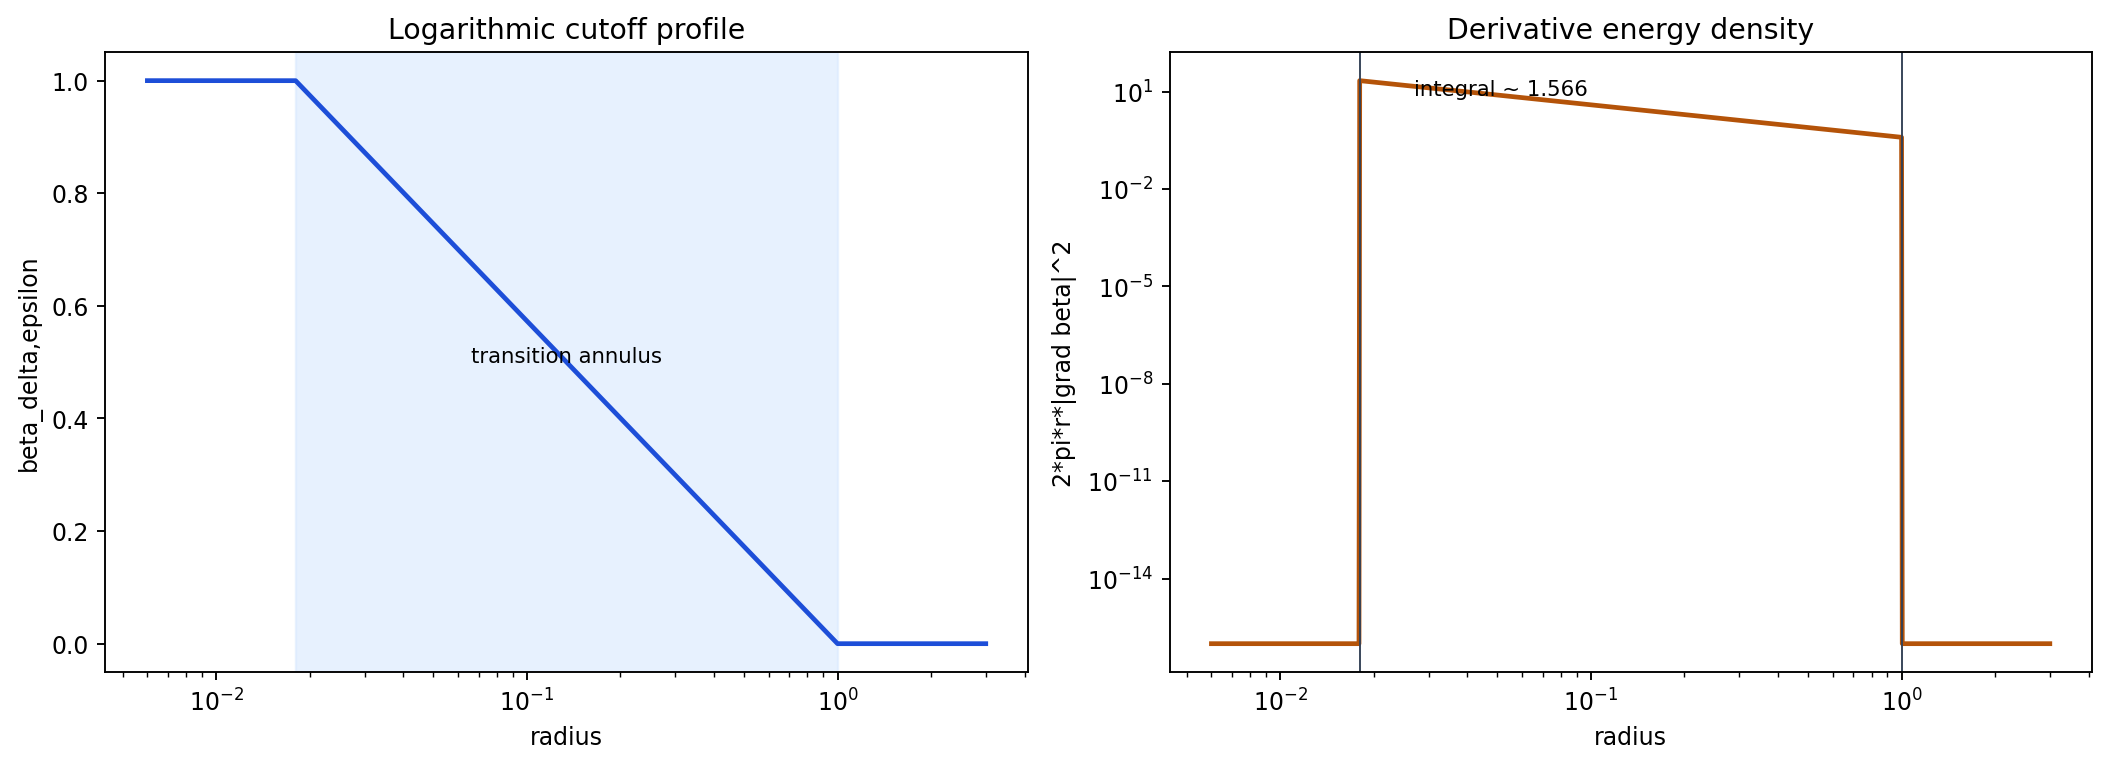

In [6]:
delta_cut = 0.018
eps_cut = 1.0
rad = np.logspace(np.log10(delta_cut / 3), np.log10(eps_cut * 3), 1200)
log_ratio = math.log(eps_cut / delta_cut)
beta = np.where(rad <= delta_cut, 1.0, np.where(rad >= eps_cut, 0.0, np.log(eps_cut / rad) / log_ratio))
deriv = np.where((rad >= delta_cut) & (rad <= eps_cut), 1.0 / (rad * log_ratio), 0.0)
energy_density = 2 * math.pi * rad * deriv**2
numeric_energy = float(trapz(energy_density, rad))
exact_energy = float(2 * math.pi / log_ratio)
relative_energy_error = abs(numeric_energy - exact_energy) / exact_energy

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
axes[0].semilogx(rad, beta, color="#1d4ed8", lw=2)
axes[0].axvspan(delta_cut, eps_cut, color="#dbeafe", alpha=0.65)
axes[0].set_ylim(-0.05, 1.05)
axes[0].set_xlabel("radius")
axes[0].set_ylabel("beta_delta,epsilon")
axes[0].set_title("Logarithmic cutoff profile")
axes[0].text(math.sqrt(delta_cut * eps_cut), 0.5, "transition annulus", ha="center", fontsize=9)

axes[1].loglog(rad, np.maximum(energy_density, 1e-16), color="#b45309", lw=2)
axes[1].axvline(delta_cut, color="#334155", lw=0.8)
axes[1].axvline(eps_cut, color="#334155", lw=0.8)
axes[1].set_xlabel("radius")
axes[1].set_ylabel("2*pi*r*|grad beta|^2")
axes[1].set_title("Derivative energy density")
axes[1].text(delta_cut * 1.5, max(energy_density) * 0.35, f"integral ~ {numeric_energy:.3f}", fontsize=9)
fig.tight_layout()
cutoff_fig = record(FIG_DIR / "cutoff-log-profile.png")
save_figure(fig, cutoff_fig, bbox_inches="tight")
plt.close(fig)

cutoff_checks = {
    "delta": delta_cut,
    "epsilon": eps_cut,
    "log_epsilon_over_delta": log_ratio,
    "numeric_derivative_energy": numeric_energy,
    "exact_derivative_energy": exact_energy,
    "relative_energy_error": relative_energy_error,
    "transition_support_fraction_log_scale": float(log_ratio / math.log((eps_cut * 3) / (delta_cut / 3))),
    "passed": bool(relative_energy_error < 0.01 and exact_energy < 2 * math.pi),
}
cutoff_json = write_json(CHECK_DIR / "cutoff-profile-checks.json", cutoff_checks)

display_artifact(cutoff_fig)
display_artifact(cutoff_json)


## Approximate Solution, Neck Error, And Newton Correction

The preglued map is not exactly `J^R`-holomorphic. The local model below separates two pieces of the error budget:

- a cutoff-supported estimate of the form `(delta R)^(-2/p)`, matching the weighted Sobolev estimate used in Section 10.3;
- an exponentially small long-cylinder term, representing the geometric intuition that a longer neck is closer to a broken curve.

The Newton step uses an exact right inverse and turns a small residual into a smaller corrected residual. The check records that the corrected model stays below the raw residual and decreases with the neck length.


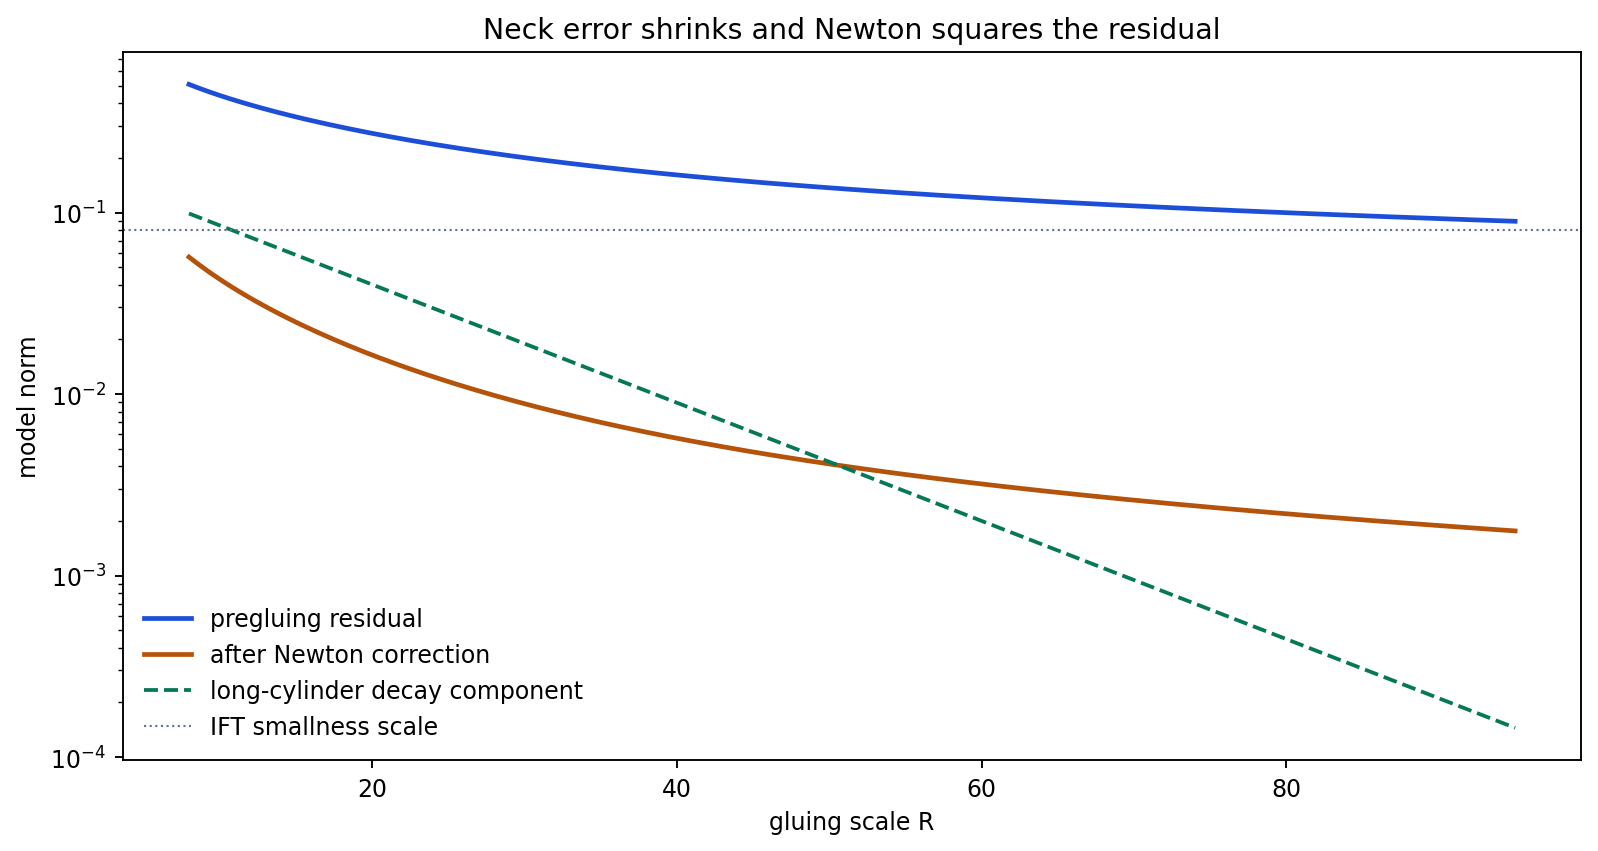

In [7]:
p_exp = 3.25
R_grid = np.linspace(8, 95, 260)
delta_error = 0.22
cutoff_error = (delta_error * R_grid) ** (-2 / p_exp)
cylinder_error = 0.18 * np.exp(-0.075 * R_grid)
raw_error = 0.58 * cutoff_error + cylinder_error
newton_constant = 0.22
corrected_error = newton_constant * raw_error**2
smallness_threshold = 0.08
threshold_index = int(np.argmax(raw_error < smallness_threshold)) if np.any(raw_error < smallness_threshold) else -1
threshold_R = float(R_grid[threshold_index]) if threshold_index >= 0 else None

fig, ax = plt.subplots(figsize=(9.5, 5.1))
ax.semilogy(R_grid, raw_error, label="pregluing residual", color="#1d4ed8", lw=2)
ax.semilogy(R_grid, corrected_error, label="after Newton correction", color="#b45309", lw=2)
ax.semilogy(R_grid, cylinder_error, label="long-cylinder decay component", color="#047857", lw=1.6, ls="--")
ax.axhline(smallness_threshold, color="#64748b", lw=0.9, ls=":", label="IFT smallness scale")
if threshold_R is not None:
    ax.axvline(threshold_R, color="#64748b", lw=0.8, ls=":")
    ax.text(threshold_R + 1, smallness_threshold * 1.18, f"R ~ {threshold_R:.1f}", fontsize=9)
ax.set_xlabel("gluing scale R")
ax.set_ylabel("model norm")
ax.set_title("Neck error shrinks and Newton squares the residual")
ax.legend(frameon=False)
fig.tight_layout()
neck_fig = record(FIG_DIR / "neck-error-newton-correction.png")
save_figure(fig, neck_fig, bbox_inches="tight")
plt.close(fig)

legacy_fig = record(FIG_DIR / "gluing-neck-error-cutoff.png")
if legacy_fig != neck_fig:
    import shutil
    shutil.copyfile(neck_fig, legacy_fig)

html_path = record(HTML_DIR / "neck-error-parameter-explorer.html")
try:
    import plotly.graph_objects as go
    fig_html = go.Figure()
    for d in [0.16, 0.22, 0.32]:
        e = 0.58 * (d * R_grid) ** (-2 / p_exp) + cylinder_error
        fig_html.add_trace(go.Scatter(x=R_grid, y=e, mode="lines", name=f"delta={d:.2f}"))
        fig_html.add_trace(go.Scatter(x=R_grid, y=newton_constant * e**2, mode="lines", name=f"Newton delta={d:.2f}", line={"dash": "dash"}))
    fig_html.update_layout(
        title="Neck-error parameter explorer",
        xaxis_title="R",
        yaxis_title="model norm",
        yaxis_type="log",
        template="plotly_white",
        legend_title="curve",
    )
    fig_html.write_html(str(html_path), include_plotlyjs="cdn", full_html=True)
    plotly_available = True
except Exception as exc:
    html_path.write_text(f"<html><body><h1>Neck-error parameter explorer</h1><p>Plotly unavailable: {exc}</p></body></html>", encoding="utf-8")
    plotly_available = False

neck_checks = {
    "p": p_exp,
    "delta": delta_error,
    "initial_raw_error": float(raw_error[0]),
    "final_raw_error": float(raw_error[-1]),
    "initial_corrected_error": float(corrected_error[0]),
    "final_corrected_error": float(corrected_error[-1]),
    "corrected_below_raw_all_samples": bool(np.all(corrected_error < raw_error)),
    "raw_error_monotone_decreasing": bool(np.all(np.diff(raw_error) < 0)),
    "threshold_R_for_smallness": threshold_R,
    "plotly_available": plotly_available,
    "passed": bool(np.all(corrected_error < raw_error) and np.all(np.diff(raw_error) < 0)),
}
neck_json = write_json(CHECK_DIR / "neck-error-newton-checks.json", neck_checks)
write_json(CHECK_DIR / "gluing-error-checks.json", neck_checks)

display_artifact(neck_fig)
display_artifact(html_path)
display_artifact(neck_json)


## From Approximate Inverse To Gluing Map

The proof first builds an approximate inverse `T` for the linearized operator at the preglued curve. The estimate has the form `||D T eta - eta|| <= 1/2 ||eta||`. This makes `D T` invertible by a Neumann series, so `Q = T(DT)^{-1}` is a true right inverse.

The derivative of the gluing map is then controlled by separating two effects: the derivative of the pregluing map and the derivative of the small Newton correction. The correction derivative is smaller by a neck factor, so the pregluing derivative determines immersion and orientation.


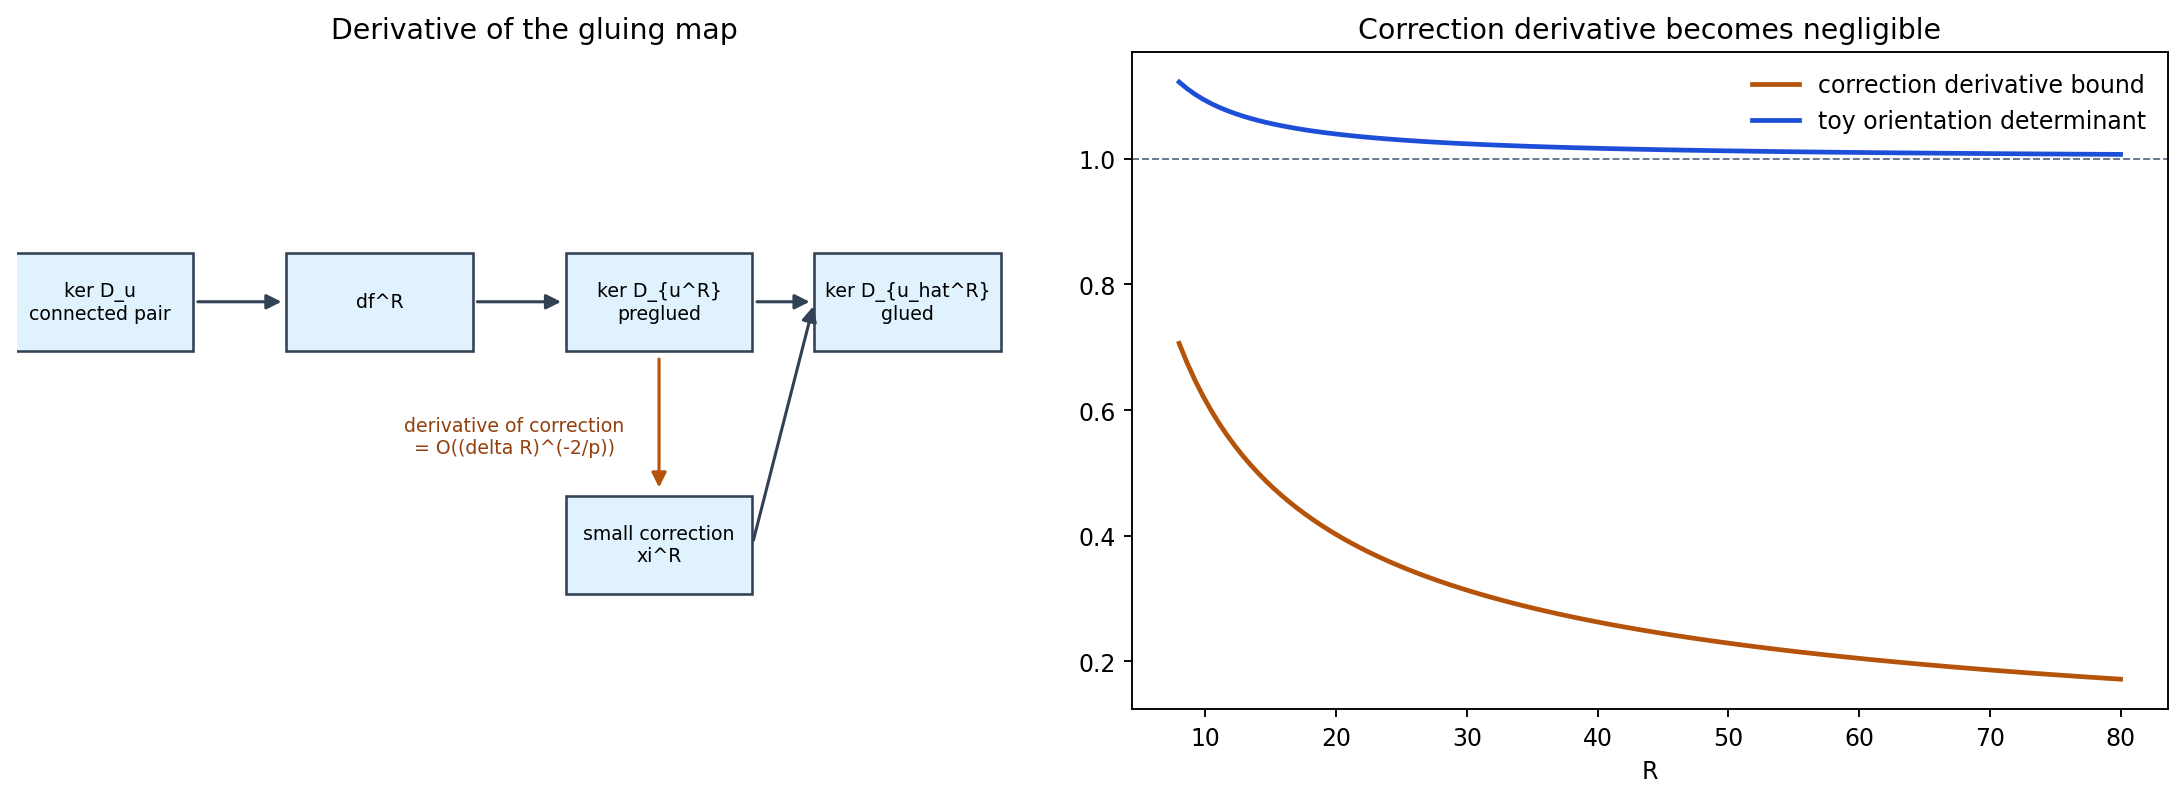

In [8]:
I = np.eye(3)
E = np.array([[0.0, 0.10, -0.04], [0.03, 0.0, 0.05], [-0.02, 0.04, 0.0]])
DT = I + E
neumann_approx = sum(np.linalg.matrix_power(-E, k) for k in range(18))
true_inverse = np.linalg.inv(DT)
neumann_residual = float(np.linalg.norm(DT @ neumann_approx - I, ord=2))
inverse_error = float(np.linalg.norm(neumann_approx - true_inverse, ord=2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
ax = axes[0]
boxes = {
    "ker D_u\nconnected pair": (0.08, 0.62),
    "df^R": (0.35, 0.62),
    "ker D_{u^R}\npreglued": (0.62, 0.62),
    "small correction\nxi^R": (0.62, 0.25),
    "ker D_{u_hat^R}\nglued": (0.86, 0.62),
}
for label, (x, y) in boxes.items():
    ax.add_patch(Rectangle((x - 0.09, y - 0.075), 0.18, 0.15, facecolor="#e0f2fe", edgecolor="#334155", lw=1.1))
    ax.text(x, y, label, ha="center", va="center", fontsize=8)
for start, end in [
    ("ker D_u\nconnected pair", "df^R"),
    ("df^R", "ker D_{u^R}\npreglued"),
    ("ker D_{u^R}\npreglued", "ker D_{u_hat^R}\nglued"),
    ("small correction\nxi^R", "ker D_{u_hat^R}\nglued"),
]:
    x0, y0 = boxes[start]
    x1, y1 = boxes[end]
    ax.add_patch(FancyArrowPatch((x0 + 0.09, y0), (x1 - 0.09, y1), arrowstyle="-|>", mutation_scale=13, lw=1.3, color="#334155"))
ax.add_patch(FancyArrowPatch((0.62, 0.54), (0.62, 0.33), arrowstyle="-|>", mutation_scale=13, lw=1.3, color="#b45309"))
ax.text(0.48, 0.39, "derivative of correction\n= O((delta R)^(-2/p))", ha="center", fontsize=8, color="#92400e")
ax.set_title("Derivative of the gluing map")
ax.axis("off")

ax = axes[1]
R_deriv = np.linspace(8, 80, 120)
neck_factor = (delta_error * R_deriv) ** (-2 / p_exp)
orientation_eps = 0.35 * neck_factor / neck_factor[0]
determinants = 1 + orientation_eps**2
ax.plot(R_deriv, neck_factor, label="correction derivative bound", color="#b45309", lw=2)
ax.plot(R_deriv, determinants, label="toy orientation determinant", color="#1d4ed8", lw=2)
ax.axhline(1, color="#64748b", lw=0.8, ls="--")
ax.set_xlabel("R")
ax.set_title("Correction derivative becomes negligible")
ax.legend(frameon=False)
fig.tight_layout()
derivative_fig = record(FIG_DIR / "derivative-gluing-map.png")
save_figure(fig, derivative_fig, bbox_inches="tight")
plt.close(fig)

linear_checks = {
    "operator_norm_E": float(np.linalg.norm(E, ord=2)),
    "DT_invertible": bool(abs(np.linalg.det(DT)) > 1e-10),
    "neumann_residual": neumann_residual,
    "neumann_inverse_error": inverse_error,
    "correction_derivative_final": float(neck_factor[-1]),
    "correction_derivative_initial": float(neck_factor[0]),
    "orientation_determinants_positive": bool(np.all(determinants > 0)),
    "passed": bool(np.linalg.norm(E, ord=2) < 0.5 and neumann_residual < 1e-8 and np.all(determinants > 0)),
}
linear_json = write_json(CHECK_DIR / "linearization-surjectivity-checks.json", linear_checks)

display_artifact(derivative_fig)
display_artifact(linear_json)


## Surjectivity: Turning Weak Closeness Into Normal Form

The image statement of the gluing theorem is not automatic. A curve that is only `C0`-close to the two limiting components must be upgraded until it has the exact form used in the implicit-function theorem: `v = exp_{u^R}(xi)` with `xi` in the image of the chosen right inverse and with small weighted `W^{1,p}` norm.

The source proof does this by successive approximation: uniqueness near the Newton chart, projection to the normal slice, compactness plus long-cylinder estimates, and finally the theorem's image conclusion.


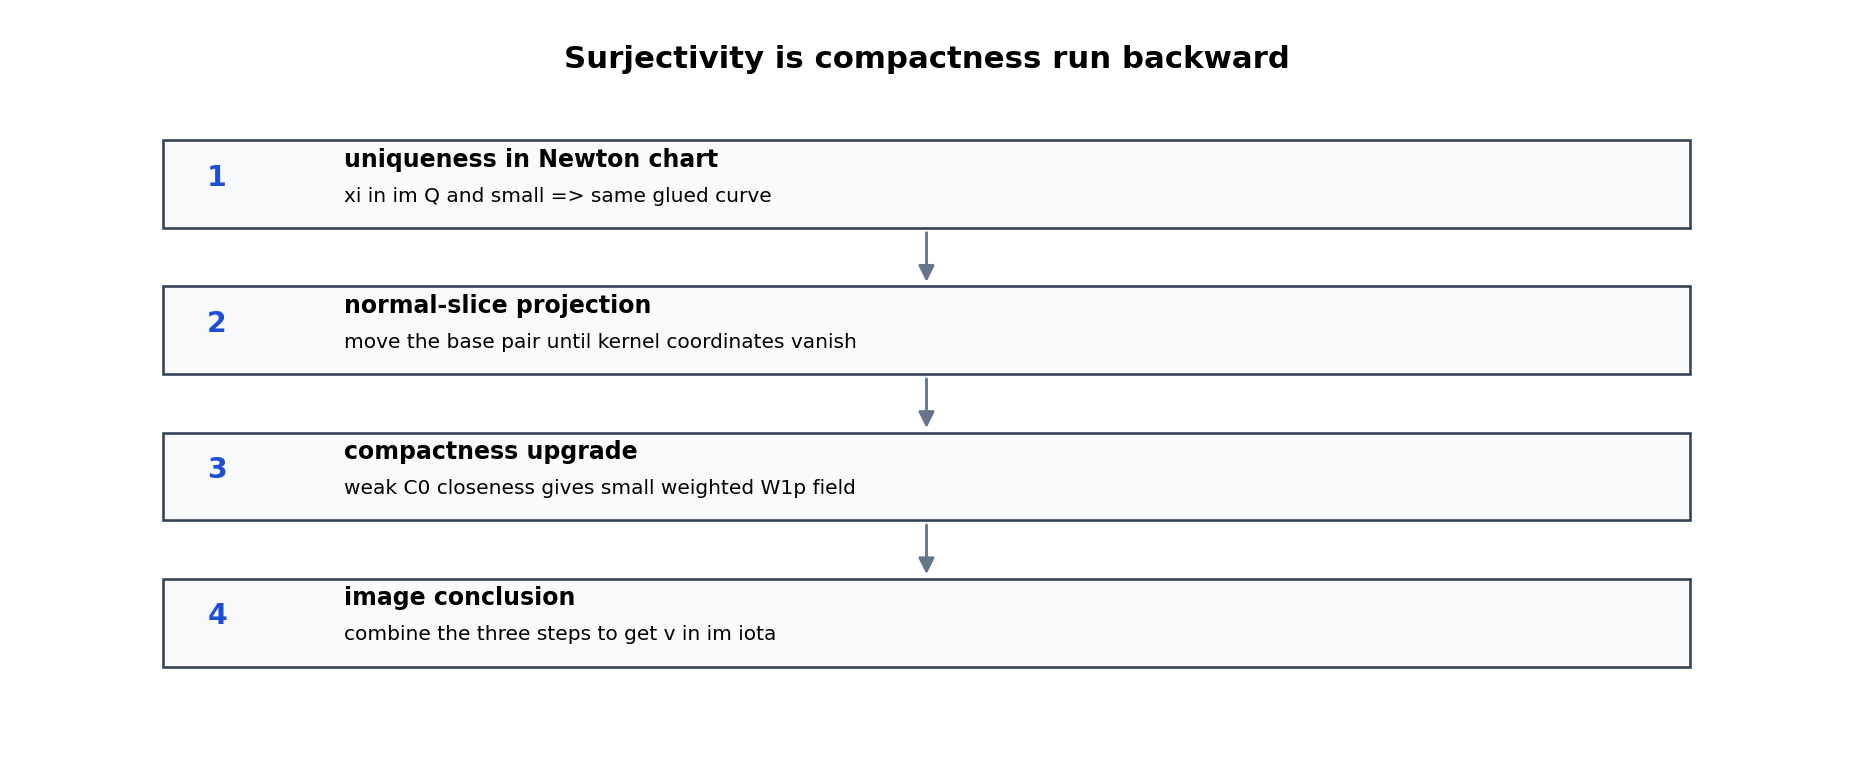

In [9]:
surj_steps = [
    ("1", "uniqueness in Newton chart", "xi in im Q and small => same glued curve"),
    ("2", "normal-slice projection", "move the base pair until kernel coordinates vanish"),
    ("3", "compactness upgrade", "weak C0 closeness gives small weighted W1p field"),
    ("4", "image conclusion", "combine the three steps to get v in im iota"),
]
fig, ax = plt.subplots(figsize=(11, 4.6))
y_positions = np.linspace(0.78, 0.18, len(surj_steps))
for (num, title, detail), y in zip(surj_steps, y_positions):
    ax.add_patch(Rectangle((0.08, y - 0.07), 0.84, 0.12, facecolor="#f8fafc", edgecolor="#334155", lw=1.1))
    ax.text(0.11, y, num, ha="center", va="center", fontsize=12, weight="bold", color="#1d4ed8")
    ax.text(0.18, y + 0.025, title, ha="left", va="center", fontsize=10, weight="bold")
    ax.text(0.18, y - 0.025, detail, ha="left", va="center", fontsize=8.5)
for y0, y1 in zip(y_positions[:-1], y_positions[1:]):
    ax.add_patch(FancyArrowPatch((0.5, y0 - 0.07), (0.5, y1 + 0.05), arrowstyle="-|>", mutation_scale=14, lw=1.2, color="#64748b"))
ax.text(0.5, 0.93, "Surjectivity is compactness run backward", ha="center", fontsize=13, weight="bold")
ax.axis("off")
fig.tight_layout()
surj_fig = record(FIG_DIR / "surjectivity-newton-steps.png")
save_figure(fig, surj_fig, bbox_inches="tight")
plt.close(fig)

surjectivity_checks = {
    "step_count": len(surj_steps),
    "has_newton_uniqueness": any("Newton" in title for _, title, _ in surj_steps),
    "has_compactness_upgrade": any("compactness" in title for _, title, _ in surj_steps),
    "has_image_conclusion": any("image" in title for _, title, _ in surj_steps),
    "passed": bool(len(surj_steps) == 4),
}
linear_checks.update({"surjectivity_steps": surjectivity_checks})
write_json(CHECK_DIR / "linearization-surjectivity-checks.json", linear_checks)

display_artifact(surj_fig)
display_artifact(CHECK_DIR / "linearization-surjectivity-checks.json")


## Splitting Axiom: The Diagonal Is The Node

For Gromov-Witten counts, gluing identifies curves near a one-node boundary stratum with pairs of curves that meet at the node. The node condition is an intersection with the diagonal in `M x M`. Splitting the diagonal through a Poincare-dual basis converts the one-piece count into a sum of paired counts.

The figure below keeps the signs and pseudocycle transversality out of the drawing and focuses on the geometry: constraints are distributed to two components, the node is the diagonal, and the gluing map turns the paired count into nearby smooth curves.


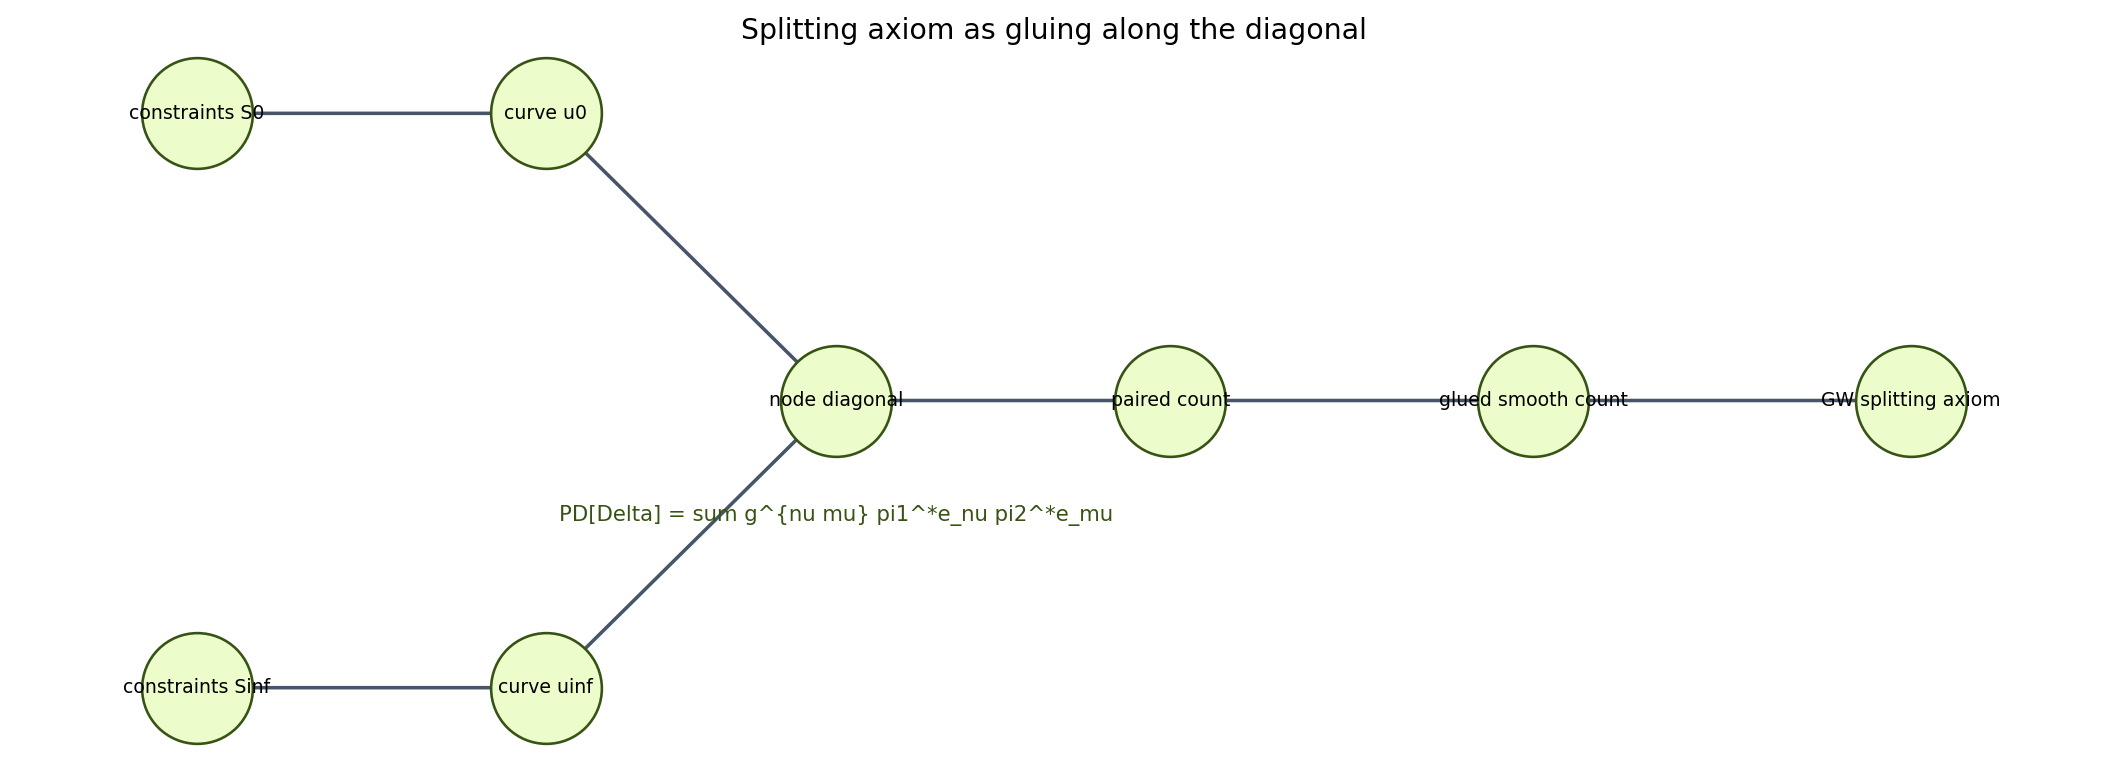

In [10]:
split_G = nx.DiGraph()
split_edges = [
    ("constraints S0", "curve u0"),
    ("constraints Sinf", "curve uinf"),
    ("curve u0", "node diagonal"),
    ("curve uinf", "node diagonal"),
    ("node diagonal", "paired count"),
    ("paired count", "glued smooth count"),
    ("glued smooth count", "GW splitting axiom"),
]
split_G.add_edges_from(split_edges)
split_pos = {
    "constraints S0": (0, 1),
    "constraints Sinf": (0, -1),
    "curve u0": (1.2, 1),
    "curve uinf": (1.2, -1),
    "node diagonal": (2.2, 0),
    "paired count": (3.35, 0),
    "glued smooth count": (4.6, 0),
    "GW splitting axiom": (5.9, 0),
}
fig, ax = plt.subplots(figsize=(12.5, 4.6))
nx.draw_networkx_edges(split_G, split_pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=14, width=1.5, edge_color="#475569")
nx.draw_networkx_nodes(split_G, split_pos, ax=ax, node_color="#ecfccb", edgecolors="#365314", node_size=2200, linewidths=1.1)
nx.draw_networkx_labels(split_G, split_pos, ax=ax, font_size=8)
ax.text(2.2, -0.42, "PD[Delta] = sum g^{nu mu} pi1^*e_nu pi2^*e_mu", ha="center", fontsize=9, color="#365314")
ax.set_title("Splitting axiom as gluing along the diagonal")
ax.axis("off")
fig.tight_layout()
splitting_fig = record(FIG_DIR / "splitting-axiom-flow.png")
save_figure(fig, splitting_fig, bbox_inches="tight")
plt.close(fig)

g_pair = sp.Matrix([[0, 1], [1, 0]])
g_inv = g_pair.inv()
N0 = sp.Matrix([3, 5])
Ninf = sp.Matrix([7, 11])
paired_total = int((N0.T * g_inv * Ninf)[0])
manual_total = int(N0[0] * Ninf[1] + N0[1] * Ninf[0])

display_artifact(splitting_fig)


## Theorem Revisited: A Disk Coordinate For The Nodal Boundary

When `J` is independent of the domain point, the one-node stratum with four marked points has a two-real-dimensional gluing parameter. After normalization, the smooth marked curve has points `(1, infinity, lambda, 0)` with

`lambda = exp(i theta) / R^2`.

Thus `lambda -> 0` is the same geometric degeneration as `R -> infinity`: a smooth four-marked curve approaches the nodal curve, and the gluing theorem supplies a neighborhood chart around that boundary stratum.


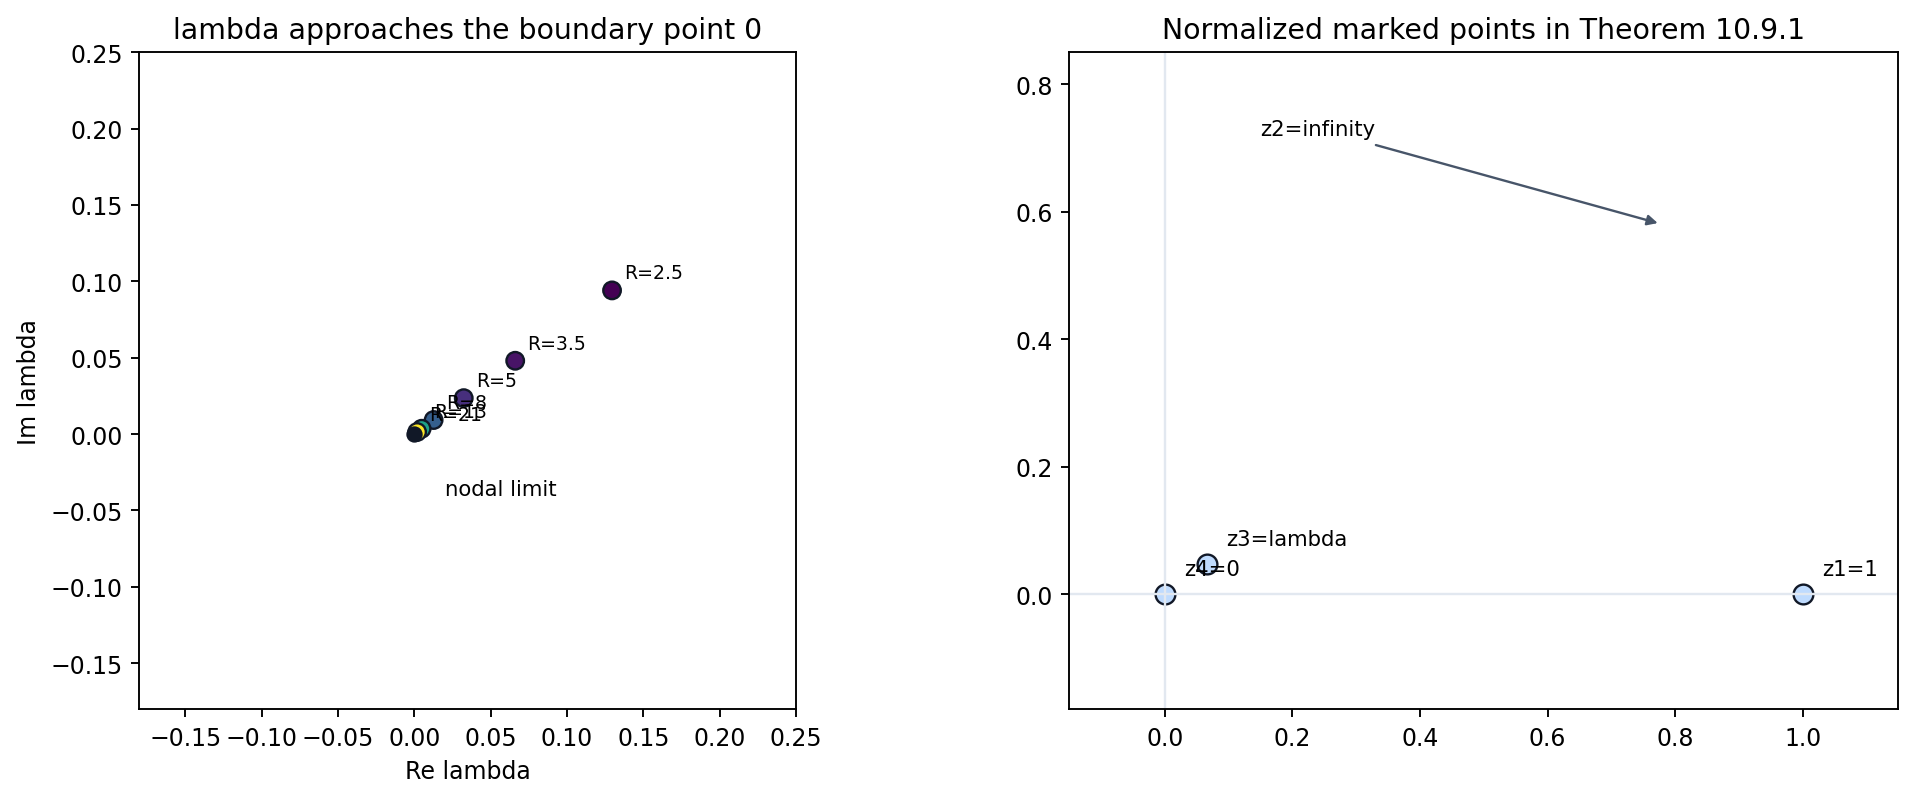

In [11]:
R_cross = np.array([2.5, 3.5, 5, 8, 13, 21], dtype=float)
theta = math.pi / 5
lambda_vals = np.exp(1j * theta) / (R_cross**2)
relation_error = float(np.max(np.abs(np.abs(lambda_vals) * R_cross**2 - 1)))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
ax = axes[0]
unit = np.exp(1j * np.linspace(0, 2 * math.pi, 300))
ax.plot(unit.real, unit.imag, color="#cbd5e1", lw=1)
ax.scatter(lambda_vals.real, lambda_vals.imag, c=R_cross, cmap="viridis", s=55, edgecolor="#111827")
for Rv, lam in zip(R_cross, lambda_vals):
    ax.text(lam.real + 0.008, lam.imag + 0.008, f"R={Rv:g}", fontsize=8)
ax.scatter([0], [0], color="#111827", s=35)
ax.text(0.02, -0.04, "nodal limit", fontsize=9)
ax.set_aspect("equal")
ax.set_xlim(-0.18, 0.25)
ax.set_ylim(-0.18, 0.25)
ax.set_xlabel("Re lambda")
ax.set_ylabel("Im lambda")
ax.set_title("lambda approaches the boundary point 0")

ax = axes[1]
finite_points = {"z1=1": 1 + 0j, "z3=lambda": lambda_vals[1], "z4=0": 0 + 0j}
ax.axhline(0, color="#e2e8f0", lw=1)
ax.axvline(0, color="#e2e8f0", lw=1)
for label, z in finite_points.items():
    ax.scatter([z.real], [z.imag], s=70, edgecolor="#111827", color="#bfdbfe")
    ax.text(z.real + 0.03, z.imag + 0.03, label, fontsize=9)
ax.annotate("z2=infinity", xy=(0.78, 0.58), xytext=(0.15, 0.72), arrowprops={"arrowstyle": "-|>", "color": "#475569"}, fontsize=9)
ax.set_aspect("equal")
ax.set_xlim(-0.15, 1.15)
ax.set_ylim(-0.18, 0.85)
ax.set_title("Normalized marked points in Theorem 10.9.1")
fig.tight_layout()
cross_fig = record(FIG_DIR / "gluing-theorem-revisited-cross-ratio.png")
save_figure(fig, cross_fig, bbox_inches="tight")
plt.close(fig)

splitting_checks = {
    "diagonal_pairing_matrix": [[int(x) for x in row] for row in g_pair.tolist()],
    "inverse_pairing_matrix": [[int(x) for x in row] for row in g_inv.tolist()],
    "paired_total": paired_total,
    "manual_total": manual_total,
    "diagonal_pairing_check": paired_total == manual_total,
    "cross_ratio_relation_max_error": relation_error,
    "lambda_moduli_decrease": bool(np.all(np.diff(np.abs(lambda_vals)) < 0)),
    "passed": bool(paired_total == manual_total and relation_error < 1e-12 and np.all(np.diff(np.abs(lambda_vals)) < 0)),
}
splitting_json = write_json(CHECK_DIR / "splitting-revisited-checks.json", splitting_checks)

display_artifact(cross_fig)
display_artifact(splitting_json)


## Invariant Ledger

This ledger is the compact audit trail for the chapter. Each row names a source concept, the computational object used here, and the invariant or check that makes the object more than a drawing.


In [12]:
ledger_rows = [
    {"source_concept": "regular connected pair", "computational_object": "node-matching proof graph", "inspection_target": "transversality feeds the first node", "check": "dependency graph is acyclic"},
    {"source_concept": "connected sum", "computational_object": "annular radius model", "inspection_target": "which annuli carry transitions", "check": "radii are strictly ordered"},
    {"source_concept": "weighted norms", "computational_object": "theta_R density", "inspection_target": "inner disk and outer region receive equal area", "check": "symbolic volume difference is zero"},
    {"source_concept": "cutoff functions", "computational_object": "logarithmic beta", "inspection_target": "derivative energy shrinks on long annuli", "check": "numeric integral matches exact formula"},
    {"source_concept": "approximate solution", "computational_object": "neck residual curve", "inspection_target": "defect decreases with R", "check": "raw residual is monotone decreasing"},
    {"source_concept": "right inverse and Newton correction", "computational_object": "finite Neumann-series model", "inspection_target": "approximate inverse becomes exact", "check": "Neumann residual is tiny"},
    {"source_concept": "derivative/gluing map", "computational_object": "tangent projection diagram", "inspection_target": "correction derivative becomes negligible", "check": "toy orientation determinants remain positive"},
    {"source_concept": "surjectivity", "computational_object": "four-step approximation ladder", "inspection_target": "weak closeness reaches normal form", "check": "all four proof moves represented"},
    {"source_concept": "splitting axiom", "computational_object": "diagonal pairing graph", "inspection_target": "node condition splits through a basis", "check": "finite pairing total equals manual sum"},
    {"source_concept": "theorem 10.9 revisit", "computational_object": "lambda disk", "inspection_target": "lambda -> 0 iff R -> infinity", "check": "|lambda| R^2 = 1"},
]
ledger_df = pd.DataFrame(ledger_rows)
ledger_csv = record(TABLE_DIR / "invariant-ledger.csv")
ledger_df.to_csv(ledger_csv, index=False)
ledger_payload = {
    "source_span": "printed pp. 369-416; PDF pp. 384-431",
    "row_count": len(ledger_rows),
    "items": [row["source_concept"] for row in ledger_rows],
    "has_source_specific_checks": all(row["check"] for row in ledger_rows),
    "passed": bool(len(ledger_rows) >= 10 and all(row["check"] for row in ledger_rows)),
}
ledger_json = write_json(CHECK_DIR / "invariant-ledger.json", ledger_payload)

display(ledger_df)
display_artifact(ledger_csv)
display_artifact(ledger_json)


,source_concept,computational_object,inspection_target,check
0,regular connected pair,node-matching proof graph,transversality feeds the first node,dependency graph is acyclic
1,connected sum,annular radius model,which annuli carry transitions,radii are strictly ordered
2,weighted norms,theta_R density,inner disk and outer region receive equal area,symbolic volume difference is zero
3,cutoff functions,logarithmic beta,derivative energy shrinks on long annuli,numeric integral matches exact formula
4,approximate solution,neck residual curve,defect decreases with R,raw residual is monotone decreasing
5,right inverse and Newton correction,finite Neumann-series model,approximate inverse becomes exact,Neumann residual is tiny
6,derivative/gluing map,tangent projection diagram,correction derivative becomes negligible,toy orientation determinants remain positive
7,surjectivity,four-step approximation ladder,weak closeness reaches normal form,all four proof moves represented
8,splitting axiom,diagonal pairing graph,node condition splits through a basis,finite pairing total equals manual sum
9,theorem 10.9 revisit,lambda disk,lambda -> 0 iff R -> infinity,|lambda| R^2 = 1


## Applied Lab: Stress The Neck Parameters

The chapter's estimates have a practical message: long necks help, but cutoffs and weights determine what "small" means. Try changing the values below and rerun this cell.

- Smaller `delta` makes the logarithmic cutoff better but forces larger admissible `R`.
- Larger `p` changes the exponent in the weighted Sobolev estimate.
- A larger Newton constant models a weaker right-inverse bound.

The lab reports the first `R` at which the corrected residual drops below the requested tolerance.


In [13]:
def lab_threshold(delta=0.22, p=3.25, newton_c=0.22, tolerance=0.01):
    R_values = np.linspace(8, 140, 500)
    raw = 0.58 * (delta * R_values) ** (-2 / p) + 0.18 * np.exp(-0.075 * R_values)
    corrected = newton_c * raw**2
    hits = np.where(corrected < tolerance)[0]
    return {
        "delta": float(delta),
        "p": float(p),
        "newton_constant": float(newton_c),
        "tolerance": float(tolerance),
        "first_R": float(R_values[hits[0]]) if len(hits) else None,
        "final_corrected_error": float(corrected[-1]),
        "monotone_corrected": bool(np.all(np.diff(corrected) < 0)),
    }


lab_cases = pd.DataFrame([
    lab_threshold(delta=0.16, p=3.25, newton_c=0.22),
    lab_threshold(delta=0.22, p=3.25, newton_c=0.22),
    lab_threshold(delta=0.32, p=3.25, newton_c=0.22),
    lab_threshold(delta=0.22, p=2.45, newton_c=0.22),
    lab_threshold(delta=0.22, p=3.25, newton_c=0.34),
])
lab_csv = record(TABLE_DIR / "neck-parameter-lab.csv")
lab_cases.to_csv(lab_csv, index=False)
display(lab_cases)
display_artifact(lab_csv)


,delta,p,newton_constant,tolerance,first_R,final_corrected_error,monotone_corrected
0,0.16,3.25,0.22,0.01,35.246493,0.001612,True
1,0.22,3.25,0.22,0.01,27.839679,0.001090,True
2,0.32,3.25,0.22,0.01,21.490982,0.000687,True
3,0.22,2.45,0.22,0.01,20.168337,0.000275,True
4,0.22,3.25,0.34,0.01,36.833667,0.001684,True


## Final Sanity Checks

The final cell asserts the contract for this chapter notebook: concept artifacts exist and are nonempty, section coverage is complete, the graph and algebraic checks pass, and the core numerical identities remain within tolerance. The resulting JSON is saved as the final machine-readable audit artifact.


In [14]:
required_sections = {f"10.{i}" for i in range(1, 10)}
missing_sections = sorted(required_sections - source_sections)

explicit_artifacts = [
    FIG_DIR / "connected-sum-domain-annuli.png",
    FIG_DIR / "weighted-norm-balance.png",
    FIG_DIR / "cutoff-log-profile.png",
    FIG_DIR / "neck-error-newton-correction.png",
    FIG_DIR / "splitting-axiom-flow.png",
]
assert_artifact(FIG_DIR / "connected-sum-domain-annuli.png", min_bytes=1000)
assert_artifact(FIG_DIR / "weighted-norm-balance.png", min_bytes=1000)
assert_artifact(CHECK_DIR / "source-coverage.json", min_bytes=128)
for path in explicit_artifacts:
    assert path.exists(), f"missing concept artifact: {path}"
    assert path.stat().st_size > 1000, f"artifact too small: {path}"

for path in ARTIFACTS:
    assert path.exists(), f"missing recorded artifact: {path}"
    min_size = 40 if path.suffix.lower() in {".json", ".csv"} else 1000
    assert path.stat().st_size > min_size, f"recorded artifact too small: {path}"

assert not missing_sections, f"missing source sections: {missing_sections}"
assert proof_checks["passed"], "proof dependency graph check failed"
assert connected_sum_checks["passed"], "connected-sum annulus check failed"
assert weighted_checks["passed"], "weighted norm check failed"
assert cutoff_checks["passed"], "cutoff profile check failed"
assert neck_checks["passed"], "neck/Newton check failed"
assert linear_checks["passed"], "linearization check failed"
assert linear_checks["surjectivity_steps"]["passed"], "surjectivity step check failed"
assert splitting_checks["passed"], "splitting/revisited check failed"
assert ledger_payload["passed"], "invariant ledger check failed"
routing_blob = " ".join(routing_df["library"].astype(str))
assert all(name in routing_blob for name in ["Matplotlib", "NetworkX", "SymPy", "Plotly"]), "library routing is incomplete"

final_payload = {
    "source_span_used": "printed pp. 369-416; PDF pp. 384-431",
    "source_sections_covered": sorted(source_sections),
    "artifact_count": len(ARTIFACTS),
    "artifacts": [{"path": rel(path), "bytes": path.stat().st_size} for path in ARTIFACTS],
    "core_checks": {
        "proof_graph_dag": bool(proof_checks["is_directed_acyclic_graph"]),
        "weighted_volume_difference": weighted_checks["symbolic_difference"],
        "cutoff_relative_energy_error": cutoff_checks["relative_energy_error"],
        "neck_error_monotone": bool(neck_checks["raw_error_monotone_decreasing"]),
        "newton_below_raw": bool(neck_checks["corrected_below_raw_all_samples"]),
        "neumann_residual": linear_checks["neumann_residual"],
        "diagonal_pairing_check": bool(splitting_checks["diagonal_pairing_check"]),
        "cross_ratio_relation_max_error": splitting_checks["cross_ratio_relation_max_error"],
    },
    "passed": True,
}
final_json = record(CHECK_DIR / "final-sanity.json")
final_json.write_text(json.dumps(final_payload, indent=2, sort_keys=True), encoding="utf-8")
assert_artifact(final_json, min_bytes=100)

display_artifact(final_json)
print("Chapter 10 sanity checks passed.")


Chapter 10 sanity checks passed.


## Takeaways

- Pregluing is a controlled connected sum: outside the transition annuli it is just the original curves, and the defect is localized.
- The weighted metric is not cosmetic. It makes the rescaled inner component visible to the same Sobolev estimates as the outer component.
- The logarithmic cutoff is tuned to the two-dimensional borderline estimate needed for a small multiplication operator.
- The approximate inverse becomes an exact right inverse by a Neumann-series argument; Newton correction then produces the actual `J^R`-holomorphic curve.
- Surjectivity is the analytic converse of compactness: weak closeness to a broken pair is upgraded to the Newton normal form.
- The splitting axiom is the counting consequence: gluing identifies a one-node boundary stratum, and the diagonal class turns node matching into a sum over paired constraints.
- The revisited four-marked theorem packages the same local model into the disk coordinate `lambda`, with the nodal curve sitting at `lambda=0`.
